# ¿Que es un Proceso Estocastico?

Un proceso estocástico {Yt} es una colección de variables aleatorias indexadas en el tiempo.

$$ y_1,y_2, ..., y_T$$


# Estacionariedad

Significa que las propiedades estadisticas(media,varianza,etc...) **permanecen constantes** a lo largo del tiempo, por lo que las series temporales con tendencias o estacionalidad no son estacioniarias

## ¿Por qué es importante la estacionariedad?

Los modelos **ARMA** requieren de estacionariedad, para poder aplicar pronosticos

## ¿Como identificar series no estacionarias?

Existen varios metodos:

1. **Visual**: Cuando hablamos de series de tiempo no estacionarias al graficarlas, es posible identificar patrones, tendencia o estacionalidad notable a medida que cambia el tiempo

2. **Estadisticos**: Podriamos calcular estadisticos descriptivos como la **media y varianza** en segmentos diferentes de tiempo. Si son diferentes se dice qu no es estacionaria

3. **Estadisticos de Prueba**: Este es un de los metodos mas robustos, son 2 pruebas, **Dickey-Fuller Aumentada & KPSS**


### Prueba **Dickey-Fuller Aumentada (ADF)**

Esta prueba como dijimos anteriormente nos sirve para saber si una Serie de tiempo es estacionaria o no.

Considera como hipotesis nula $H_0$ que la serie temporal tiene una raiz unitaria (cosa que es muy **frecuente** en series de tiempo **NO estacionarias**)

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{k} \delta_i \Delta y_{t-i} + \varepsilon_t$$


- $\alpha$: Es la constante (intercepto).
- $\beta t$: Es la tendencia determinística.
- $\gamma y_{t-1}$: Es el término que se evalúa para ver si hay una raíz unitaria (si $\gamma = 0$, la serie no es estacionaria).
- $\sum \delta_i \Delta y_{t-i}$: Son los rezagos de la variable diferenciada, que se agregan para eliminar la autocorrelación en los residuos.

De aqui salen varias dudas:

¿Que quiere decir **"Raiz Unitaria"**?

Imagina que tiras una pelota que está unida a un resorte. Si la golpeas (un "choque" o error), la pelota se mueve, pero el resorte la **jala de vuelta** a su posición original.

Ahora imagina que la pelota no tiene resorte y está en un piso perfectamente liso.
- Si le das un golpe, la pelota se mueve y **se queda ahí**, en el nuevo lugar.
- Si le das otro golpe, se mueve desde esa nueva posición a otra.
- No tiene **"memoria"** de dónde estaba al principio; no hay nada que la jale de vuelta.

Ahora veamoslo de vuelta a la serie

- Sin raíz unitaria: La serie regresa a su media (es mean-reverting).(Por lo que **TIENDE a ser estacionaria**)
- Con raíz unitaria: La serie vaga sin rumbo fijo y su varianza crece con el tiempo. (Por lo que **NO tiende a ser estacionaria**)

#### Prueba

Queremos que el p_value nos de < 0.05 para **rechazar $H_0$**
- $H_0$: La serie tiene una raíz unitaria, no es estacionaria.
- $H_A$: La serie no tiene raíz unitaria, es estacionaria.

### Prueba **Kwiatkowski-Phillips-Schmidt-Shin (KPSS)**

La prueba KPSS comprueba si una serie temporal es estacionaria en torno a una media o una tendencia lineal.

$$yt=ξt+rt+εt$$
- $r_t$ es caminata aleatoria donde los errores son normales 
- $εt$ es un error aleatorio

La prueba consiste en que:
- $H_0$: Es estacionaria
- $H_A$: No es estacionaria

Por lo que si nos dan los p_values menores a 0.05 se rechaza la $H_0$ de que la serie es estacionaria, por lo que nos tocaria diferenciar

---

Para arreglar tu serie temporal y volverla **estacionaria**, existe un metodo muy bueno el cual se llama **diferenciacion** de la serie temporal

### Diferenciacion

La diferenciación puede ayudar a estabilizar la media de una serie temporal eliminando cambios en el nivel de una serie temporal y, por lo tanto, eliminando (o reduciendo) la tendencia y la estacionalidad.

$$Δy_t=y_t−y_{t−1}$$

- Esta es conocida como diferenciación de primer orden. Este proceso se puede repetir si es necesario hasta que se alcance la estacionariedad deseada. Sin embargo, tiene una penalizacion y es que mientras mas ordenes menos es la interpretacion


---

### Funcion de **Autocorrelacion (ACF)**

Este grafico tambien ayuda para ver si una serie temporal es estacionaria o no

- En una serie temporal estacionaria, la ACF se reducirá a cero con relativa rapidez
- En datos no estacionarios la ACF disminuye lentamente, ademas, el valor de ρ1
 suele ser alto y positivo.


$$ρk=γk/γ0=Cov(Yt,Yt−k)/Var(Yt) $$


# Serie de tiempo de Colombia

In [2]:
import wbgapi as wb

# Definimos el país (COL) y el indicador (PIB)
country_code = 'COL'
indicator = 'NY.GDP.MKTP.CD'

# Descargamos los datos
# mrnev=50 asegura que traigamos los últimos 50 años disponibles
gdp_col = wb.data.DataFrame(indicator, country_code, mrnev=50)

# Limpieza básica: Transponer para tener los años en las filas
gdp_col = gdp_col.T
gdp_col.index = gdp_col.index.str.replace('YR', '').astype(int)
gdp_col.columns = ['PIB_Colombia']

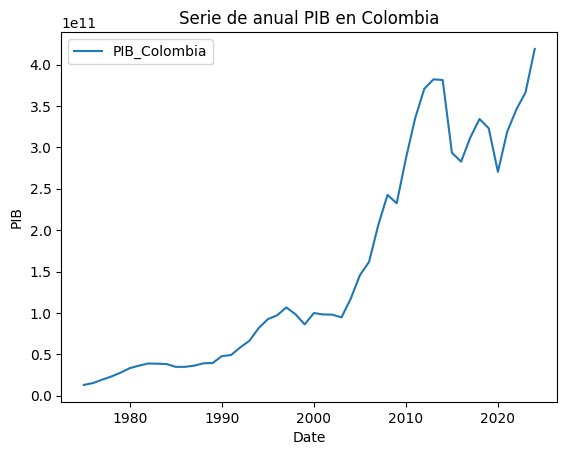

In [11]:
import matplotlib.pyplot as plt

gdp_col.plot()
plt.xlabel("Date")
plt.ylabel("PIB")
plt.title("Serie de anual PIB en Colombia")
plt.show()

## Verificando la Autocorrelacion

### ACF

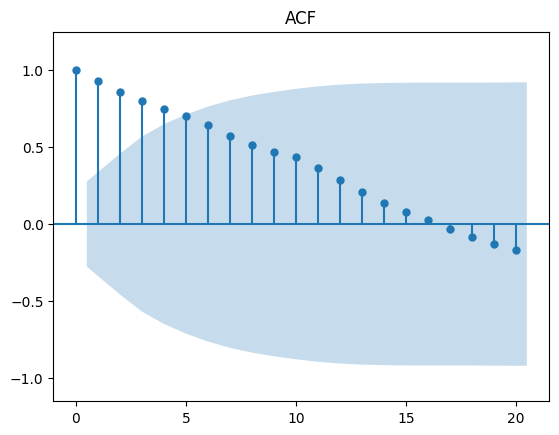

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(gdp_col, lags=20,auto_ylims=True)
plt.title("ACF")
plt.show()

### PACF

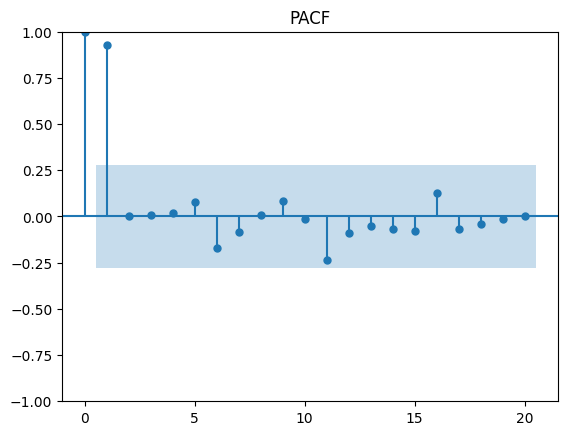

In [15]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(gdp_col, lags=20)
plt.title("PACF")
plt.show()

### Ljung-Box

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(gdp_col, lags=20, return_df=True)
lb_test.mean()

lb_stat      2.325408e+02
lb_pvalue    7.044811e-13
dtype: float64

## Verificar Estacionariedad

### ADF & KPSS

In [20]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

adf_result = adfuller(gdp_col)
kpss_result = kpss(gdp_col, regression='c')

tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
})

tab_test

/tmp/ipykernel_14493/2218702876.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(gdp_col, regression='c')


,Test,Estadístico,P-valor,Estacionario
0,Prueba Augmented Dickey-Fuller (ADF),0.1570,0.9697,No
1,Prueba KPSS,1.0083,0.0100,No


## Aplicar Diferenciacion (debido a la NO estacionariedad)

In [21]:
# Primera diferencia de la serie integrada de orden 1
pib_diff = gdp_col.diff().dropna()

## Verificar Autocorrelacion (Orden 1)

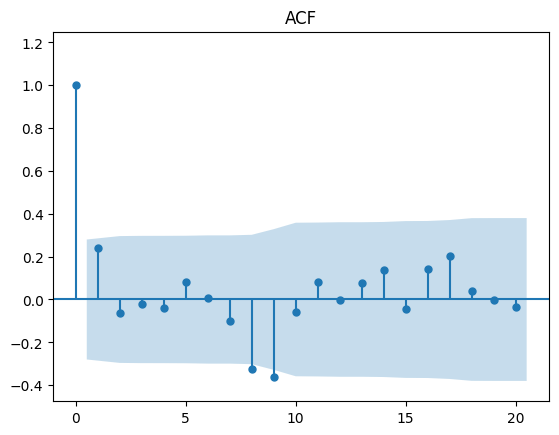

In [25]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(pib_diff, lags=20,auto_ylims=True)
plt.title("ACF")
plt.show()

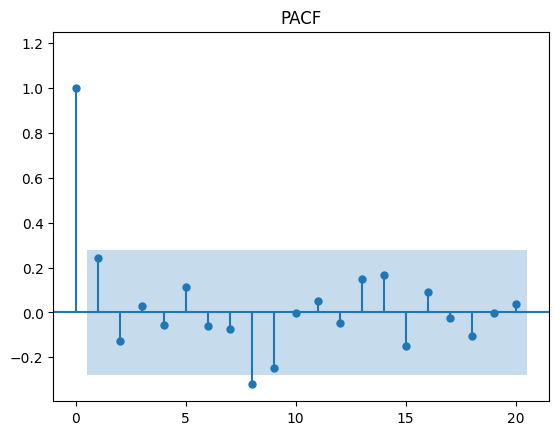

In [27]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(pib_diff, lags=20,auto_ylims=True)
plt.title("PACF")
plt.show()

## Verificar Estacionariedad (Orden 1)

In [28]:
adfuller = adfuller(pib_diff)
kpss = kpss(pib_diff, regression='c')

tests = pd.DataFrame({
    "Estadisticos":[adfuller[0],adfuller[1]],
    "p_values":[kpss[0],kpss[1]],
    "Estacionario?":["Si" if adfuller[1] < 0.05 else "No", "No" if kpss[1] < 0.05 else "Sí"]
})

tests

/tmp/ipykernel_14493/2874042024.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss = kpss(pib_diff, regression='c')


,Estadisticos,p_values,Estacionario?
0,-4.989401,0.179462,Si
1,0.000023,0.100000,Sí
